# Entrenamiento de CNN sencilla para reconocimiento de dígitos MNIST

**Andres Santiago Acevedo Porras**

**Andres Felipe Serrano Alvarez**

**Materia:** IA en Hardware Digital  
**Objetivo:** entrenar, evaluar y exportar una red neuronal convolucional sencilla para clasificar dígitos manuscritos del 0 al 9 usando imágenes de **28×28 píxeles**.

Este notebook incluye:

1. Importación de librerías.  
2. Carga de MNIST.  
3. Visualización de imágenes.  
4. Preprocesamiento.  
5. División entrenamiento / validación / prueba.  
6. Definición de una CNN sencilla optimizada para hardware.  
7. Entrenamiento con aumento de datos.  
8. Gráficas de precisión y pérdida.  
9. Evaluación con datos de prueba.  
10. Matriz de confusión.  
11. Interfaz gráfica para dibujar un número.  
12. Exportación de modelo, pesos, bias, estructura, archivos `.npy`, `.csv`, `.txt`, `.hex` y `.coe`.

---

## Decisión de diseño

Se usa una **CNN sencilla**, no una MLP, porque las CNN aprovechan la estructura espacial de las imágenes. El modelo se mantiene pequeño para facilitar su futura implementación en hardware digital.

La salida del modelo se deja en formato **logits**, no como `softmax`. Para software se puede aplicar `softmax` y obtener probabilidades, pero para hardware digital basta con usar un bloque **argmax**, que selecciona la salida mayor.

# 0. Requisitos del entorno

Este notebook está pensado para ejecutarse en **Jupyter Notebook** o **JupyterLab** con Python 3.

Librerías necesarias:

- TensorFlow / Keras
- NumPy
- Matplotlib
- Pandas
- Scikit-learn
- Pillow
- Tkinter, incluido normalmente con Python en Windows

Si alguna librería no está instalada, se puede instalar desde una celda del notebook quitando el comentario `#` de las líneas siguientes.

In [1]:
# Ejecutar solo si hace falta instalar dependencias.

#%pip install tensorflow numpy matplotlib pandas scikit-learn pillow

# 1. Importación de librerías

En esta sección se importan las herramientas necesarias para cargar MNIST, crear la CNN, entrenarla, visualizar resultados, calcular métricas y exportar los pesos para hardware.

In [2]:
import os
import json
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
keras = tf.keras
layers = tf.keras.layers

from sklearn.metrics import confusion_matrix, classification_report

from PIL import Image, ImageOps, ImageDraw

# Semilla para reproducibilidad.
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("Todo está funcionando correctamente")
print("TensorFlow:", tf.__version__)
print("NumPy:", np.__version__)
print("Pandas:", pd.__version__)
print("Keras desde TensorFlow:", keras.__name__)
print("GPU:", tf.config.list_physical_devices("GPU"))

Todo está funcionando correctamente
TensorFlow: 2.21.0
NumPy: 1.26.4
Pandas: 2.3.3
Keras desde TensorFlow: keras._tf_keras.keras
GPU: []


# 2. Carga del dataset MNIST

MNIST contiene imágenes de dígitos manuscritos del 0 al 9. Cada imagen tiene tamaño **28×28 píxeles** en escala de grises.

Keras entrega el dataset dividido originalmente en:

- 60.000 imágenes de entrenamiento.
- 10.000 imágenes de prueba.

Más adelante se separará una parte del entrenamiento para validación.

In [3]:
# Carga directa desde Keras.
(x_train_full, y_train_full), (x_test, y_test) = keras.datasets.mnist.load_data()

print("x_train_full:", x_train_full.shape)
print("y_train_full:", y_train_full.shape)
print("x_test:", x_test.shape)
print("y_test:", y_test.shape)
print("Clases:", np.unique(y_train_full))

x_train_full: (60000, 28, 28)
y_train_full: (60000,)
x_test: (10000, 28, 28)
y_test: (10000,)
Clases: [0 1 2 3 4 5 6 7 8 9]


# 3. Visualización de algunas imágenes

Antes de entrenar el modelo, se revisan ejemplos del dataset para confirmar que las imágenes corresponden a dígitos manuscritos y que el tamaño es correcto.

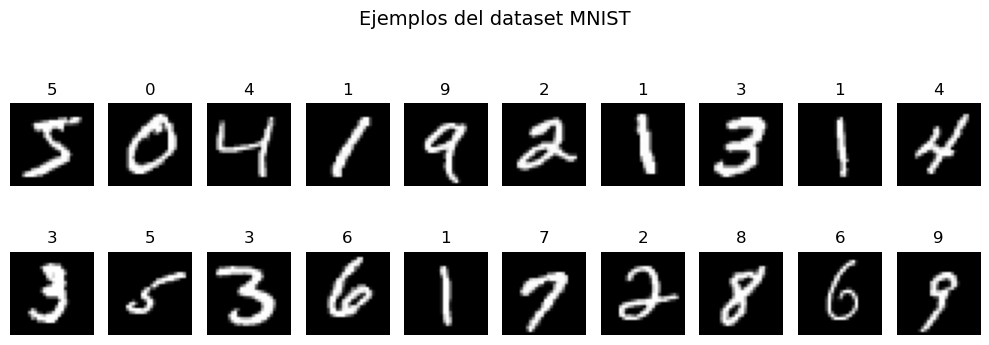

In [4]:
plt.figure(figsize=(10, 4))
for i in range(20):
    plt.subplot(2, 10, i + 1)
    plt.imshow(x_train_full[i], cmap="gray")
    plt.title(str(y_train_full[i]))
    plt.axis("off")
plt.suptitle("Ejemplos del dataset MNIST", fontsize=14)
plt.tight_layout()
plt.show()

# 4. Preprocesamiento

El modelo espera imágenes con forma:

```text
28 × 28 × 1
```

Por eso se realizan tres pasos:

1. Convertir los datos a `float32`.
2. Normalizar los píxeles dividiendo entre 255, para dejar valores entre 0 y 1.
3. Agregar el canal de escala de grises, pasando de `(28, 28)` a `(28, 28, 1)`.

Para las etiquetas se usarán **etiquetas enteras** y la función de pérdida `SparseCategoricalCrossentropy`. Esto evita hacer one-hot encoding y simplifica el flujo.

In [5]:
# Normalización y cambio de forma.
x_train_full = x_train_full.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

# Agregar canal: de (N, 28, 28) a (N, 28, 28, 1)
x_train_full = np.expand_dims(x_train_full, axis=-1)
x_test = np.expand_dims(x_test, axis=-1)

# Etiquetas como enteros.
y_train_full = y_train_full.astype("int64")
y_test = y_test.astype("int64")

print("x_train_full:", x_train_full.shape)
print("x_test:", x_test.shape)
print("Rango de pixeles:", x_train_full.min(), "a", x_train_full.max())

x_train_full: (60000, 28, 28, 1)
x_test: (10000, 28, 28, 1)
Rango de pixeles: 0.0 a 1.0


# 5. División entrenamiento / validación / prueba

Se usa la división oficial de MNIST para prueba y se reserva una parte del conjunto de entrenamiento para validación.

Distribución usada:

- **Entrenamiento:** 50.000 imágenes.
- **Validación:** 10.000 imágenes.
- **Prueba:** 10.000 imágenes.

La validación permite verificar si el modelo está aprendiendo bien sin usar todavía el conjunto final de prueba.

In [6]:
# Mezclar antes de separar entrenamiento y validación.
indices = np.arange(x_train_full.shape[0])
np.random.shuffle(indices)

x_train_full = x_train_full[indices]
y_train_full = y_train_full[indices]

VAL_SIZE = 10_000

x_val = x_train_full[:VAL_SIZE]
y_val = y_train_full[:VAL_SIZE]

x_train = x_train_full[VAL_SIZE:]
y_train = y_train_full[VAL_SIZE:]

print("Entrenamiento:", x_train.shape, y_train.shape)
print("Validación:", x_val.shape, y_val.shape)
print("Prueba:", x_test.shape, y_test.shape)

Entrenamiento: (50000, 28, 28, 1) (50000,)
Validación: (10000, 28, 28, 1) (10000,)
Prueba: (10000, 28, 28, 1) (10000,)


# 6. Aumento de datos para mejorar robustez

Un problema común con MNIST es que los números suelen estar centrados. Si el usuario dibuja un número desplazado a la izquierda, derecha, arriba o abajo, un modelo entrenado solo con imágenes centradas puede fallar.

Para reducir ese problema, se aplican transformaciones moderadas durante el entrenamiento:

- Rotación pequeña.
- Desplazamiento horizontal y vertical.
- Zoom suave.

No se usan volteos horizontales ni verticales, porque un dígito volteado puede dejar de representar el mismo número.

In [7]:
# Aumento de datos moderado.
# RandomRotation(0.03) equivale aproximadamente a ±10.8 grados porque el factor es fracción de una vuelta completa.
# RandomTranslation(0.10) equivale aproximadamente a ±2.8 píxeles en una imagen de 28 píxeles.

data_augmentation = keras.Sequential(
    [
        layers.RandomRotation(factor=0.03, fill_mode="constant", fill_value=0.0, seed=SEED),
        layers.RandomTranslation(height_factor=0.10, width_factor=0.10, fill_mode="constant", fill_value=0.0, seed=SEED),
        layers.RandomZoom(height_factor=(-0.10, 0.10), width_factor=(-0.10, 0.10), fill_mode="constant", fill_value=0.0, seed=SEED),
    ],
    name="aumento_datos_entrenamiento"
)

## Visualización del aumento de datos

La siguiente celda muestra cómo una misma imagen puede generar variantes ligeramente rotadas, desplazadas o escaladas. Esto ayuda a que el modelo sea más robusto cuando se pruebe con números dibujados por el usuario.

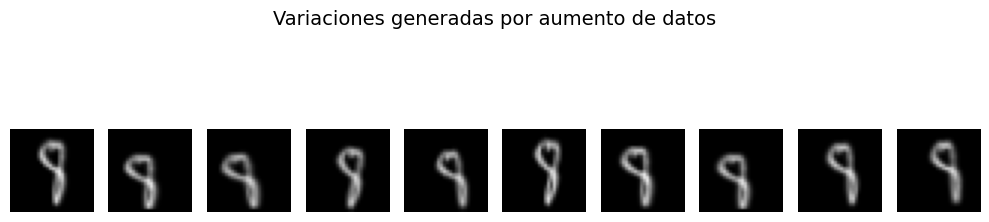

In [8]:
example = x_train[0:1]

plt.figure(figsize=(10, 3))
for i in range(10):
    augmented = data_augmentation(example, training=True)
    plt.subplot(1, 10, i + 1)
    plt.imshow(augmented[0, :, :, 0], cmap="gray", vmin=0, vmax=1)
    plt.axis("off")
plt.suptitle("Variaciones generadas por aumento de datos", fontsize=14)
plt.tight_layout()
plt.show()

# 7. Preparación de datasets eficientes con `tf.data`

Se crean lotes de entrenamiento, validación y prueba. El aumento de datos se aplica solo al conjunto de entrenamiento.

La validación y la prueba se mantienen sin aumento para medir el desempeño real del modelo.

In [9]:
BATCH_SIZE = 128
AUTOTUNE = tf.data.AUTOTUNE

train_ds_clean = tf.data.Dataset.from_tensor_slices((x_train, y_train))
train_ds_clean = train_ds_clean.shuffle(buffer_size=10_000, seed=SEED).batch(BATCH_SIZE)

# Dataset de entrenamiento con aumento de datos.
def augment_batch(images, labels):
    images = data_augmentation(images, training=True)
    return images, labels

train_ds = train_ds_clean.map(augment_batch, num_parallel_calls=AUTOTUNE).prefetch(AUTOTUNE)

# Dataset de entrenamiento sin aumento, útil para evaluar precisión limpia de entrenamiento.
train_ds_eval = tf.data.Dataset.from_tensor_slices((x_train, y_train)).batch(BATCH_SIZE).prefetch(AUTOTUNE)
val_ds = tf.data.Dataset.from_tensor_slices((x_val, y_val)).batch(BATCH_SIZE).prefetch(AUTOTUNE)
test_ds = tf.data.Dataset.from_tensor_slices((x_test, y_test)).batch(BATCH_SIZE).prefetch(AUTOTUNE)

# 8. Definición de la CNN sencilla

Arquitectura seleccionada:

```text
Entrada: 28×28×1
Conv2D: 8 filtros de 3×3 + ReLU
MaxPooling2D: 2×2
Conv2D: 16 filtros de 3×3 + ReLU
MaxPooling2D: 2×2
Flatten
Dense: 32 neuronas + ReLU
Dense: 10 salidas lineales, una por clase
Argmax para obtener la clase final
```

La última capa no usa `softmax` directamente. Durante el entrenamiento se usa una pérdida compatible con logits. Para mostrar probabilidades en la interfaz, se aplicará `tf.nn.softmax` solo en software.

In [10]:
def build_cnn_hardware_friendly():
    """Construye una CNN pequeña pensada para clasificación MNIST y exportación a hardware."""
    model = keras.Sequential(
        [
            layers.Input(shape=(28, 28, 1), name="entrada_28x28x1"),
            layers.Conv2D(filters=8, kernel_size=(3, 3), activation="relu", padding="valid", name="conv1_3x3_8"),
            layers.MaxPooling2D(pool_size=(2, 2), name="pool1_2x2"),
            layers.Conv2D(filters=16, kernel_size=(3, 3), activation="relu", padding="valid", name="conv2_3x3_16"),
            layers.MaxPooling2D(pool_size=(2, 2), name="pool2_2x2"),
            layers.Flatten(name="flatten"),
            layers.Dense(32, activation="relu", name="dense1_32"),
            layers.Dense(10, activation="linear", name="logits_10"),
        ],
        name="CNN_MNIST_Hardware_Friendly"
    )
    return model

model = build_cnn_hardware_friendly()

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=["accuracy"]
)

model.summary()

Model: "CNN_MNIST_Hardware_Friendly"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1_3x3_8 (Conv2D)            │ (None, 26, 26, 8)      │            80 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool1_2x2 (MaxPooling2D)        │ (None, 13, 13, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2_3x3_16 (Conv2D)           │ (None, 11, 11, 16)     │         1,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool2_2x2 (MaxPooling2D)        │ (None, 5, 5, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 400)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense1_32 (Dense)               │ (None, 32)             │        12,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ logits_10 (Dense)               │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,410 (56.29 KB)

 Trainable params: 14,410 (56.29 KB)

 Non-trainable params: 0 (0.00 B)

## Tabla de arquitectura, tamaños y parámetros

Esta tabla resume la relación entre capas, tamaño de salida, pesos y operaciones aproximadas. 

In [11]:
hardware_summary = pd.DataFrame(
    [
        {
            "Bloque": "Entrada",
            "Tipo de operación": "Imagen normalizada",
            "Tamaño de salida": "28×28×1",
            "Pesos/Bias": 0,
            "MACs aprox.": 0,
            "Comentario hardware": "Memoria de imagen de entrada"
        },
        {
            "Bloque": "Conv1 + ReLU",
            "Tipo de operación": "Convolución 3×3, 8 filtros",
            "Tamaño de salida": "26×26×8",
            "Pesos/Bias": (3*3*1*8) + 8,
            "MACs aprox.": 26*26*8*3*3*1,
            "Comentario hardware": "8 filtros pequeños; salida pasa por ReLU"
        },
        {
            "Bloque": "MaxPool1",
            "Tipo de operación": "Pooling máximo 2×2",
            "Tamaño de salida": "13×13×8",
            "Pesos/Bias": 0,
            "MACs aprox.": 0,
            "Comentario hardware": "Comparadores, no multiplicadores"
        },
        {
            "Bloque": "Conv2 + ReLU",
            "Tipo de operación": "Convolución 3×3, 16 filtros",
            "Tamaño de salida": "11×11×16",
            "Pesos/Bias": (3*3*8*16) + 16,
            "MACs aprox.": 11*11*16*3*3*8,
            "Comentario hardware": "Mayor cantidad de MACs del modelo"
        },
        {
            "Bloque": "MaxPool2",
            "Tipo de operación": "Pooling máximo 2×2",
            "Tamaño de salida": "5×5×16",
            "Pesos/Bias": 0,
            "MACs aprox.": 0,
            "Comentario hardware": "Reduce el tamaño de los mapas"
        },
        {
            "Bloque": "Flatten",
            "Tipo de operación": "Reordenamiento",
            "Tamaño de salida": "400",
            "Pesos/Bias": 0,
            "MACs aprox.": 0,
            "Comentario hardware": "No requiere pesos; solo direccionamiento"
        },
        {
            "Bloque": "Dense1 + ReLU",
            "Tipo de operación": "Capa densa 400→32",
            "Tamaño de salida": "32",
            "Pesos/Bias": (400*32) + 32,
            "MACs aprox.": 400*32,
            "Comentario hardware": "Principal consumo de memoria por pesos"
        },
        {
            "Bloque": "Dense2 / Logits",
            "Tipo de operación": "Capa densa 32→10",
            "Tamaño de salida": "10",
            "Pesos/Bias": (32*10) + 10,
            "MACs aprox.": 32*10,
            "Comentario hardware": "Salida de 10 clases; usar argmax"
        },
    ]
)

hardware_summary.loc["TOTAL"] = [
    "TOTAL",
    "Modelo completo",
    "10 clases",
    int(hardware_summary["Pesos/Bias"].sum()),
    int(hardware_summary["MACs aprox."].sum()),
    "Softmax no es necesario en hardware; basta argmax"
]

hardware_summary

,Bloque,Tipo de operación,Tamaño de salida,Pesos/Bias,MACs aprox.,Comentario hardware
0,Entrada,Imagen normalizada,28×28×1,0,0,Memoria de imagen de entrada
1,Conv1 + ReLU,"Convolución 3×3, 8 filtros",26×26×8,80,48672,8 filtros pequeños; salida pasa por ReLU
2,MaxPool1,Pooling máximo 2×2,13×13×8,0,0,"Comparadores, no multiplicadores"
3,Conv2 + ReLU,"Convolución 3×3, 16 filtros",11×11×16,1168,139392,Mayor cantidad de MACs del modelo
4,MaxPool2,Pooling máximo 2×2,5×5×16,0,0,Reduce el tamaño de los mapas
5,Flatten,Reordenamiento,400,0,0,No requiere pesos; solo direccionamiento
6,Dense1 + ReLU,Capa densa 400→32,32,12832,12800,Principal consumo de memoria por pesos
7,Dense2 / Logits,Capa densa 32→10,10,330,320,Salida de 10 clases; usar argmax
TOTAL,TOTAL,Modelo completo,10 clases,14410,201184,Softmax no es necesario en hardware; basta argmax


## Diagrama de arquitectura

La siguiente celda genera un diagrama simple con la relación de tamaños y pesos por bloque. El archivo se guardará como imagen `.png`.

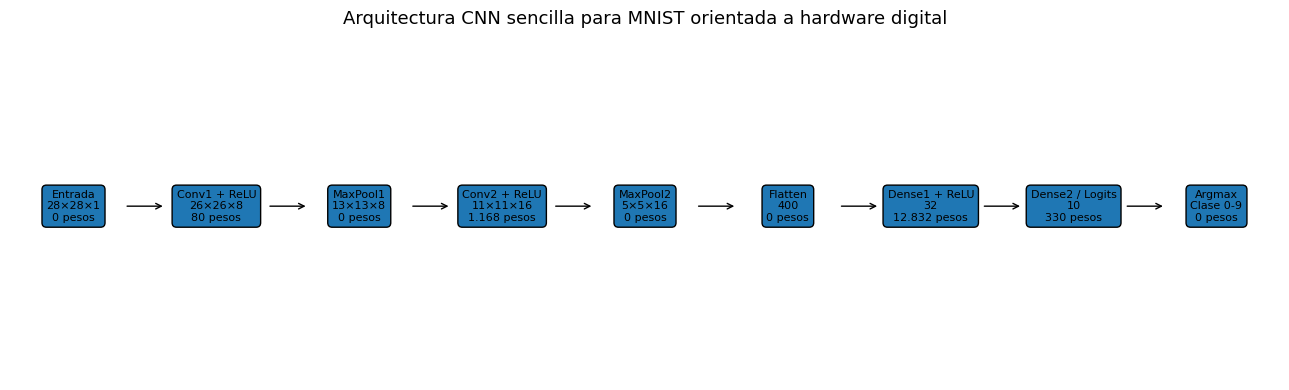

In [12]:
# Carpeta de exportación preliminar.
EXPORT_DIR = Path("export_hardware_cnn_mnist")
EXPORT_DIR.mkdir(exist_ok=True)

blocks = [
    ("Entrada", "28×28×1", "0 pesos"),
    ("Conv1 + ReLU", "26×26×8", "80 pesos"),
    ("MaxPool1", "13×13×8", "0 pesos"),
    ("Conv2 + ReLU", "11×11×16", "1.168 pesos"),
    ("MaxPool2", "5×5×16", "0 pesos"),
    ("Flatten", "400", "0 pesos"),
    ("Dense1 + ReLU", "32", "12.832 pesos"),
    ("Dense2 / Logits", "10", "330 pesos"),
    ("Argmax", "Clase 0-9", "0 pesos"),
]

fig, ax = plt.subplots(figsize=(13, 4))
ax.axis("off")

x_positions = np.linspace(0.05, 0.95, len(blocks))
y = 0.5

for i, (name, shape, weights) in enumerate(blocks):
    ax.text(
        x_positions[i], y,
        f"{name}\n{shape}\n{weights}",
        ha="center", va="center", fontsize=8,
        bbox=dict(boxstyle="round,pad=0.4", linewidth=1)
    )
    if i < len(blocks) - 1:
        ax.annotate(
            "", xy=(x_positions[i+1]-0.04, y), xytext=(x_positions[i]+0.04, y),
            arrowprops=dict(arrowstyle="->", linewidth=1)
        )

ax.set_title("Arquitectura CNN sencilla para MNIST orientada a hardware digital", fontsize=13)
plt.tight_layout()
plt.savefig(EXPORT_DIR / "diagrama_arquitectura_cnn_hardware.png", dpi=300, bbox_inches="tight")
plt.show()

# 9. Entrenamiento del modelo

Se entrena la CNN usando aumento de datos en el conjunto de entrenamiento. También se usa `EarlyStopping` para recuperar los mejores pesos según la pérdida de validación.

In [13]:
EPOCHS = 10

callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=3,
        restore_best_weights=True,
        verbose=1
    )
]

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks
)

Epoch 1/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.7472 - loss: 0.7970 - val_accuracy: 0.9428 - val_loss: 0.1914
Epoch 2/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9113 - loss: 0.2932 - val_accuracy: 0.9610 - val_loss: 0.1319
Epoch 3/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.9358 - loss: 0.2154 - val_accuracy: 0.9687 - val_loss: 0.1067
Epoch 4/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9434 - loss: 0.1859 - val_accuracy: 0.9717 - val_loss: 0.0923
Epoch 5/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9525 - loss: 0.1590 - val_accuracy: 0.9767 - val_loss: 0.0797
Epoch 6/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9508 - loss: 0.1606 - val_accuracy: 0.9763 - val_loss: 0.0787
Epoch 7/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9557 - loss: 0.1446 - val_accuracy: 0.9795 - val_loss: 0.0719
Epoch 8/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9618 - loss: 0.1278 - val_accuracy: 0

# 10. Gráficas de precisión y pérdida

Se grafican:

- Precisión de entrenamiento.
- Precisión de validación.
- Pérdida de entrenamiento.
- Pérdida de validación.

Estas gráficas permiten revisar si el modelo aprendió correctamente o si hay señales de sobreajuste.

In [14]:
history_df = pd.DataFrame(history.history)
history_df

,accuracy,loss,val_accuracy,val_loss
0,0.74718,0.797022,0.9428,0.191374
1,0.91126,0.293216,0.9610,0.131867
2,0.93576,0.215395,0.9687,0.106669
3,0.94338,0.185884,0.9717,0.092260
4,0.95248,0.158992,0.9767,0.079719
5,0.95078,0.160559,0.9763,0.078656
6,0.95568,0.144578,0.9795,0.071943
7,0.96180,0.127754,0.9793,0.071487
8,0.96230,0.125250,0.9783,0.074426
9,0.96470,0.113959,0.9795,0.070561


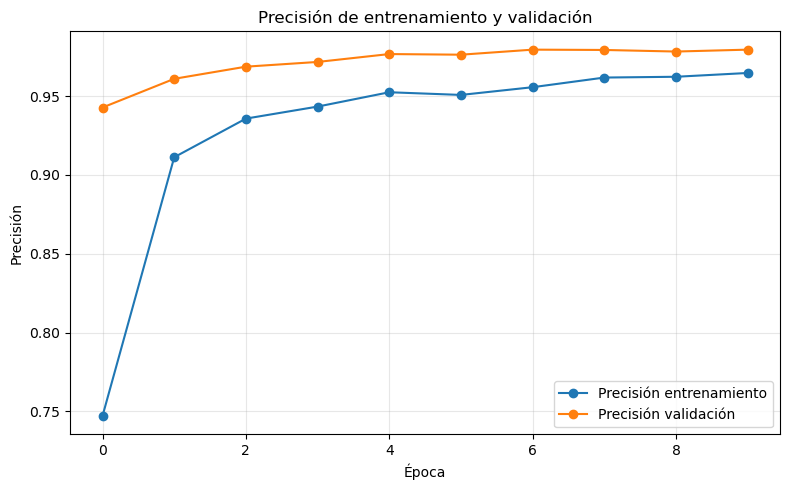

In [15]:
plt.figure(figsize=(8, 5))
plt.plot(history.history["accuracy"], marker="o", label="Precisión entrenamiento")
plt.plot(history.history["val_accuracy"], marker="o", label="Precisión validación")
plt.xlabel("Época")
plt.ylabel("Precisión")
plt.title("Precisión de entrenamiento y validación")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

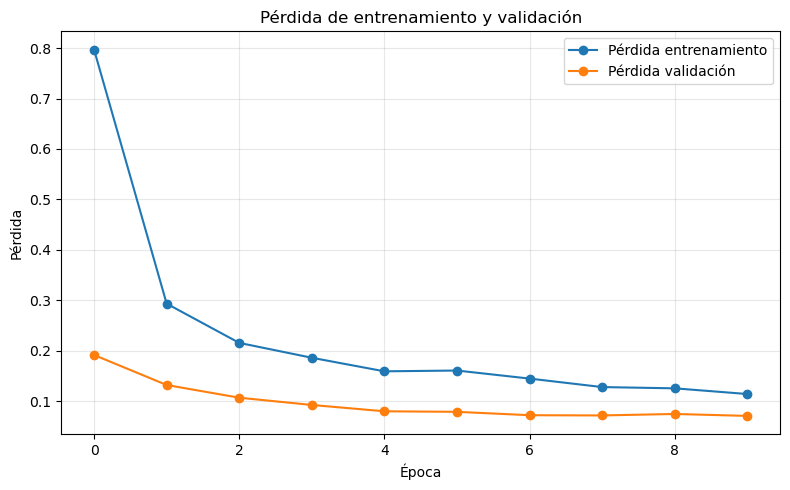

In [16]:
plt.figure(figsize=(8, 5))
plt.plot(history.history["loss"], marker="o", label="Pérdida entrenamiento")
plt.plot(history.history["val_loss"], marker="o", label="Pérdida validación")
plt.xlabel("Época")
plt.ylabel("Pérdida")
plt.title("Pérdida de entrenamiento y validación")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# 11. Evaluación con entrenamiento, validación y prueba

Aquí se reportan las métricas obligatorias:

- Precisión de entrenamiento.
- Precisión de validación.
- Precisión de prueba.
- Error/pérdida de validación.

La prueba final se hace con datos que no fueron usados para entrenar ni validar.

In [17]:
train_loss, train_acc = model.evaluate(train_ds_eval, verbose=0)
val_loss, val_acc = model.evaluate(val_ds, verbose=0)
test_loss, test_acc = model.evaluate(test_ds, verbose=0)

metrics_report = pd.DataFrame(
    {
        "Métrica": [
            "Precisión de entrenamiento",
            "Precisión de validación",
            "Precisión de prueba",
            "Pérdida de validación",
            "Pérdida de prueba",
        ],
        "Valor": [
            train_acc,
            val_acc,
            test_acc,
            val_loss,
            test_loss,
        ],
    }
)

metrics_report["Valor"] = metrics_report["Valor"].map(lambda x: f"{x:.6f}")
metrics_report

,Métrica,Valor
0,Precisión de entrenamiento,0.979340
1,Precisión de validación,0.979500
2,Precisión de prueba,0.982700
3,Pérdida de validación,0.070561
4,Pérdida de prueba,0.054972


# 12. Matriz de confusión

La matriz de confusión muestra cuántas imágenes de cada clase fueron clasificadas correctamente y cuáles se confundieron con otros números.

Esto es útil para identificar errores típicos, por ejemplo, confundir 4 con 9, 3 con 8 o 5 con 6.

In [18]:
# Predicción sobre el conjunto de prueba.
logits_test = model.predict(x_test, batch_size=BATCH_SIZE, verbose=0)
y_pred = np.argmax(logits_test, axis=1)

cm = confusion_matrix(y_test, y_pred)
cm_df = pd.DataFrame(cm, index=[f"Real {i}" for i in range(10)], columns=[f"Pred {i}" for i in range(10)])
cm_df

,Pred 0,Pred 1,Pred 2,Pred 3,Pred 4,Pred 5,Pred 6,Pred 7,Pred 8,Pred 9
Real 0,965,0,3,0,0,0,4,1,5,2
Real 1,0,1119,2,5,0,0,1,1,7,0
Real 2,2,3,1001,17,0,0,0,6,3,0
Real 3,0,0,0,1005,0,3,0,1,1,0
Real 4,0,2,0,0,962,0,3,1,2,12
Real 5,0,0,2,7,0,876,1,0,6,0
Real 6,0,2,1,0,3,2,946,0,4,0
Real 7,0,1,5,6,1,0,0,1007,3,5
Real 8,1,0,1,3,0,3,3,0,962,1
Real 9,0,0,0,9,7,4,0,1,4,984


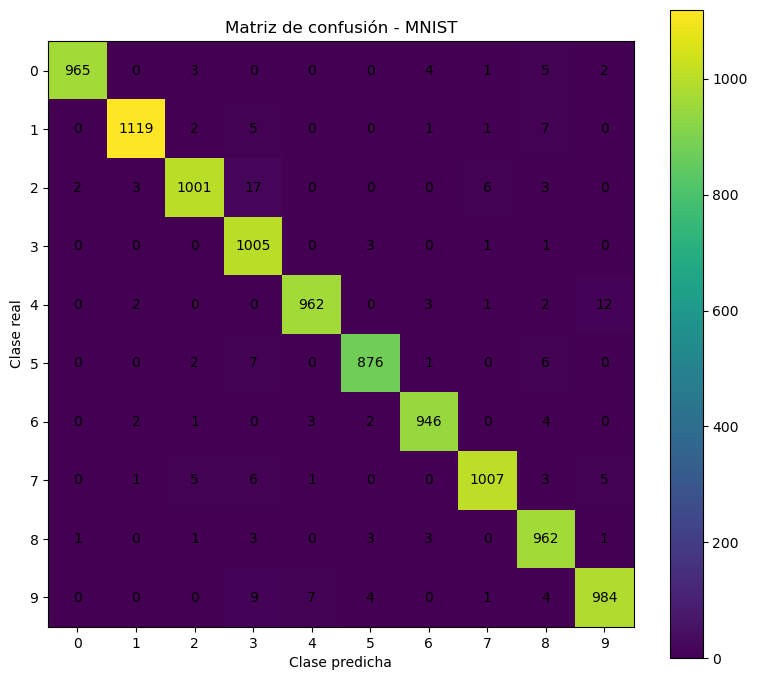

In [19]:
plt.figure(figsize=(8, 7))
plt.imshow(cm, interpolation="nearest")
plt.title("Matriz de confusión - MNIST")
plt.xlabel("Clase predicha")
plt.ylabel("Clase real")
plt.colorbar()

classes = np.arange(10)
plt.xticks(classes, classes)
plt.yticks(classes, classes)

# Escribir los valores dentro de cada celda.
threshold = cm.max() / 2
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.tight_layout()
plt.show()

In [20]:
print(classification_report(y_test, y_pred, digits=4))

              precision    recall  f1-score   support

           0     0.9969    0.9847    0.9908       980
           1     0.9929    0.9859    0.9894      1135
           2     0.9862    0.9700    0.9780      1032
           3     0.9553    0.9950    0.9748      1010
           4     0.9887    0.9796    0.9841       982
           5     0.9865    0.9821    0.9843       892
           6     0.9875    0.9875    0.9875       958
           7     0.9892    0.9796    0.9844      1028
           8     0.9649    0.9877    0.9762       974
           9     0.9801    0.9752    0.9776      1009

    accuracy                         0.9827     10000
   macro avg     0.9828    0.9827    0.9827     10000
weighted avg     0.9829    0.9827    0.9827     10000



# 13. Prueba de robustez con imágenes desplazadas

Esta sección evalúa qué tan bien responde el modelo cuando las imágenes se desplazan unos píxeles. Es una prueba útil porque la interfaz gráfica puede generar números no perfectamente centrados.

No reemplaza la matriz de confusión, pero ayuda a justificar el aumento de datos.

In [21]:
def shift_images_zero_fill(images, dx=0, dy=0):
    """
    Desplaza imágenes 28x28x1 sin hacer wrap-around.
    dx > 0 mueve a la derecha; dx < 0 mueve a la izquierda.
    dy > 0 mueve hacia abajo; dy < 0 mueve hacia arriba.
    """
    shifted = np.zeros_like(images)
    n, h, w, c = images.shape

    src_x0 = max(0, -dx)
    src_x1 = min(w, w - dx)
    dst_x0 = max(0, dx)
    dst_x1 = min(w, w + dx)

    src_y0 = max(0, -dy)
    src_y1 = min(h, h - dy)
    dst_y0 = max(0, dy)
    dst_y1 = min(h, h + dy)

    shifted[:, dst_y0:dst_y1, dst_x0:dst_x1, :] = images[:, src_y0:src_y1, src_x0:src_x1, :]
    return shifted

# Se usa una muestra para que la prueba sea rápida.
N_ROBUST = 2000
x_robust = x_test[:N_ROBUST]
y_robust = y_test[:N_ROBUST]

shifts = [
    (0, 0, "Sin desplazamiento"),
    (-3, 0, "3 px izquierda"),
    (3, 0, "3 px derecha"),
    (0, -3, "3 px arriba"),
    (0, 3, "3 px abajo"),
]

robust_results = []
for dx, dy, label in shifts:
    x_shifted = shift_images_zero_fill(x_robust, dx=dx, dy=dy)
    logits = model.predict(x_shifted, batch_size=BATCH_SIZE, verbose=0)
    pred = np.argmax(logits, axis=1)
    acc = np.mean(pred == y_robust)
    robust_results.append({"Prueba": label, "dx": dx, "dy": dy, "Precisión": acc})

robust_df = pd.DataFrame(robust_results)
robust_df["Precisión"] = robust_df["Precisión"].map(lambda x: f"{x:.4f}")
robust_df

,Prueba,dx,dy,Precisión
0,Sin desplazamiento,0,0,0.9770
1,3 px izquierda,-3,0,0.9590
2,3 px derecha,3,0,0.9490
3,3 px arriba,0,-3,0.9325
4,3 px abajo,0,3,0.9290


# 14. Funciones de preprocesamiento para imágenes dibujadas

La interfaz gráfica recibe dibujos hechos por el usuario. Esos dibujos normalmente tienen fondo blanco y trazo negro, mientras que MNIST usa fondo negro y dígito claro.

Por eso se aplica este flujo:

1. Convertir a escala de grises.
2. Invertir si el fondo es blanco.
3. Detectar el área donde está el dígito.
4. Recortar el dígito.
5. Redimensionar manteniendo proporción.
6. Centrar en una imagen de 28×28.
7. Normalizar entre 0 y 1.

In [22]:
# Compatibilidad con versiones nuevas y antiguas de Pillow.
try:
    RESAMPLE_LANCZOS = Image.Resampling.LANCZOS
    RESAMPLE_NEAREST = Image.Resampling.NEAREST
except AttributeError:
    RESAMPLE_LANCZOS = Image.LANCZOS
    RESAMPLE_NEAREST = Image.NEAREST


def preprocess_pil_digit(pil_img, final_size=28, digit_size=20, threshold=20):
    """
    Preprocesa una imagen PIL dibujada por el usuario para convertirla al formato MNIST.

    Retorna:
    - x_model: arreglo con forma (1, 28, 28, 1), normalizado entre 0 y 1.
    - img_28: imagen PIL 28x28 procesada, útil para visualizar.
    """
    # Convertir a escala de grises.
    img = pil_img.convert("L")

    # Si el fondo es claro, invertir para obtener fondo negro y trazo blanco.
    arr = np.array(img)
    if arr.mean() > 127:
        img = ImageOps.invert(img)
        arr = np.array(img)

    # Eliminar ruido débil.
    arr[arr < threshold] = 0

    # Buscar pixeles del dígito.
    ys, xs = np.where(arr > 0)

    # Si no hay dibujo, devolver imagen vacía.
    if len(xs) == 0 or len(ys) == 0:
        empty = Image.fromarray(np.zeros((final_size, final_size), dtype=np.uint8))
        x_model = np.zeros((1, final_size, final_size, 1), dtype="float32")
        return x_model, empty

    # Recortar alrededor del dígito.
    x_min, x_max = xs.min(), xs.max()
    y_min, y_max = ys.min(), ys.max()
    cropped = Image.fromarray(arr[y_min:y_max + 1, x_min:x_max + 1])

    # Redimensionar manteniendo proporción para que el lado mayor mida digit_size.
    w, h = cropped.size
    if w > h:
        new_w = digit_size
        new_h = max(1, int(round(h * digit_size / w)))
    else:
        new_h = digit_size
        new_w = max(1, int(round(w * digit_size / h)))

    resized = cropped.resize((new_w, new_h), RESAMPLE_LANCZOS)

    # Pegar centrado en lienzo 28x28.
    canvas = Image.fromarray(np.zeros((final_size, final_size), dtype=np.uint8))
    left = (final_size - new_w) // 2
    top = (final_size - new_h) // 2
    canvas.paste(resized, (left, top))

    # Normalizar.
    x = np.array(canvas).astype("float32") / 255.0
    x_model = x.reshape(1, final_size, final_size, 1)

    return x_model, canvas


def predict_digit_from_pil(pil_img, trained_model=model):
    """Predice el dígito de una imagen PIL usando el modelo entrenado."""
    x_model, img_28 = preprocess_pil_digit(pil_img)
    logits = trained_model.predict(x_model, verbose=0)[0]
    probs = tf.nn.softmax(logits).numpy()
    pred = int(np.argmax(probs))
    conf = float(np.max(probs))
    return pred, conf, probs, img_28

## Prueba rápida del preprocesamiento con una imagen de MNIST

Esta celda permite verificar que la función de predicción funcione antes de abrir la interfaz gráfica.

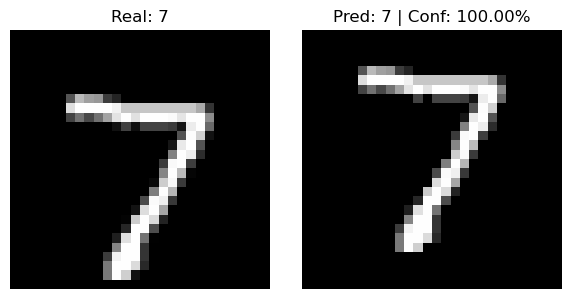

In [23]:
idx = 0
img_test_pil = Image.fromarray((x_test[idx, :, :, 0] * 255).astype(np.uint8))
pred, conf, probs, img_28 = predict_digit_from_pil(img_test_pil)

plt.figure(figsize=(6, 3))
plt.subplot(1, 2, 1)
plt.imshow(img_test_pil, cmap="gray")
plt.title(f"Real: {y_test[idx]}")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(img_28, cmap="gray")
plt.title(f"Pred: {pred} | Conf: {conf:.2%}")
plt.axis("off")
plt.tight_layout()
plt.show()

# 15. Interfaz gráfica para dibujar un número

Esta interfaz abre una ventana donde se puede:

- Dibujar un número.
- Limpiar el dibujo.
- Preprocesar a 28×28.
- Mostrar la imagen procesada.
- Predecir el número.
- Mostrar la probabilidad o confianza.

**Nota:** esta celda está pensada para Jupyter Notebook local en Windows/Linux/macOS. En Google Colab puede no funcionar porque Colab no permite abrir ventanas Tkinter locales.

In [24]:
def launch_digit_drawer_gui(trained_model=model):
    """
    Abre una ventana Tkinter para dibujar un número y clasificarlo con la CNN entrenada.
    """
    import tkinter as tk
    from PIL import ImageTk

    CANVAS_SIZE = 280
    LINE_WIDTH = 18

    root = tk.Tk()
    root.title("Reconocimiento de dígitos MNIST - CNN")
    root.resizable(False, False)

    # Imagen PIL blanca donde se dibuja internamente.
    pil_canvas = Image.new("L", (CANVAS_SIZE, CANVAS_SIZE), color=255)
    draw = ImageDraw.Draw(pil_canvas)

    last_pos = {"x": None, "y": None}

    title = tk.Label(root, text="Dibuja un número del 0 al 9", font=("Arial", 14, "bold"))
    title.grid(row=0, column=0, columnspan=3, pady=8)

    canvas = tk.Canvas(root, width=CANVAS_SIZE, height=CANVAS_SIZE, bg="white", cursor="cross")
    canvas.grid(row=1, column=0, padx=10, pady=10)

    right_frame = tk.Frame(root)
    right_frame.grid(row=1, column=1, padx=10, pady=10, sticky="n")

    processed_title = tk.Label(right_frame, text="Imagen procesada 28×28", font=("Arial", 11, "bold"))
    processed_title.pack(pady=(0, 5))

    processed_label = tk.Label(right_frame)
    processed_label.pack(pady=5)

    result_label = tk.Label(right_frame, text="Predicción: -", font=("Arial", 13, "bold"))
    result_label.pack(pady=8)

    confidence_label = tk.Label(right_frame, text="Confianza: -", font=("Arial", 11))
    confidence_label.pack(pady=4)

    probs_label = tk.Label(right_frame, text="", justify="left", font=("Consolas", 9))
    probs_label.pack(pady=4)

    def start_draw(event):
        last_pos["x"] = event.x
        last_pos["y"] = event.y

    def draw_motion(event):
        x, y = event.x, event.y
        lx, ly = last_pos["x"], last_pos["y"]
        if lx is not None and ly is not None:
            canvas.create_line(lx, ly, x, y, fill="black", width=LINE_WIDTH, capstyle=tk.ROUND, smooth=True)
            draw.line([lx, ly, x, y], fill=0, width=LINE_WIDTH)
        last_pos["x"] = x
        last_pos["y"] = y

    def stop_draw(event):
        last_pos["x"] = None
        last_pos["y"] = None

    def clear_canvas():
        nonlocal pil_canvas, draw
        canvas.delete("all")
        pil_canvas = Image.new("L", (CANVAS_SIZE, CANVAS_SIZE), color=255)
        draw = ImageDraw.Draw(pil_canvas)
        result_label.config(text="Predicción: -")
        confidence_label.config(text="Confianza: -")
        probs_label.config(text="")
        processed_label.config(image="")
        processed_label.image = None

    def predict_canvas():
        pred, conf, probs, img_28 = predict_digit_from_pil(pil_canvas, trained_model)

        # Mostrar imagen 28x28 ampliada para que se vea bien.
        img_big = img_28.resize((140, 140), RESAMPLE_NEAREST)
        tk_img = ImageTk.PhotoImage(img_big)
        processed_label.config(image=tk_img)
        processed_label.image = tk_img

        result_label.config(text=f"Predicción: {pred}")
        confidence_label.config(text=f"Confianza: {conf:.2%}")

        probs_text = "Probabilidades:\n" + "\n".join([f"{i}: {p:.3f}" for i, p in enumerate(probs)])
        probs_label.config(text=probs_text)

    canvas.bind("<Button-1>", start_draw)
    canvas.bind("<B1-Motion>", draw_motion)
    canvas.bind("<ButtonRelease-1>", stop_draw)

    button_frame = tk.Frame(root)
    button_frame.grid(row=2, column=0, columnspan=2, pady=8)

    predict_button = tk.Button(button_frame, text="Predecir", command=predict_canvas, width=15, font=("Arial", 11, "bold"))
    predict_button.grid(row=0, column=0, padx=8)

    clear_button = tk.Button(button_frame, text="Limpiar", command=clear_canvas, width=15, font=("Arial", 11))
    clear_button.grid(row=0, column=1, padx=8)

    root.mainloop()


# Ejecutar esta línea para abrir la interfaz gráfica.
# Si estás en Google Colab, esta interfaz no se abrirá.
launch_digit_drawer_gui(model)

# 16. Exportación para hardware digital

En esta sección se exporta todo lo necesario para una implementación posterior en hardware:

- Modelo completo `.keras`.
- Pesos del modelo.
- Estructura del modelo en `.json`.
- Resumen de capas en `.csv`.
- Pesos y bias por capa en `.npy`, `.csv`, `.txt`.
- Versión cuantizada `int8` en `.npy`, `.hex` y `.coe`.
- Escalas de cuantización en `.json`.

La exportación `.hex` y `.coe` es útil para inicializar memorias ROM/RAM en FPGA.

La cuantización usada aquí es **simétrica por tensor**:

```text
q = round(valor_float / escala)
escala = max(abs(valor_float)) / 127
```

Esto es una primera aproximación. Para una implementación final en hardware, también se debe validar la precisión del modelo cuantizado.

In [25]:
EXPORT_DIR = Path("export_hardware_cnn_mnist")
WEIGHTS_DIR = EXPORT_DIR / "pesos_por_capa"
WEIGHTS_DIR.mkdir(parents=True, exist_ok=True)

# 1. Guardar modelo completo en formato Keras.
model.save(EXPORT_DIR / "modelo_cnn_mnist.keras")

# 2. Guardar solo pesos en formato H5.
model.save_weights(EXPORT_DIR / "pesos_cnn_mnist.weights.h5")

# 3. Guardar estructura del modelo en JSON.
model_json = model.to_json()
with open(EXPORT_DIR / "estructura_modelo.json", "w", encoding="utf-8") as f:
    f.write(model_json)

# 4. Guardar tabla de arquitectura.
hardware_summary.to_csv(EXPORT_DIR / "resumen_capas_hardware.csv", index=False, encoding="utf-8")

print("Modelo y estructura guardados en:", EXPORT_DIR.resolve())

Modelo y estructura guardados en: C:\Users\santi\OneDrive\Escritorio\Adelanto parcial final IA en HW\export_hardware_cnn_mnist


## Funciones auxiliares para exportar pesos

Los pesos se exportan tanto en punto flotante como en formato cuantizado `int8`.

Para hardware digital, el formato `int8` es más conveniente porque reduce la memoria y simplifica la aritmética frente a `float32`.

In [26]:
def quantize_int8_symmetric(array):
    """
    Cuantización simétrica int8 por tensor.
    Retorna arreglo int8 y escala usada.
    """
    array = np.asarray(array, dtype=np.float32)
    max_abs = float(np.max(np.abs(array))) if array.size > 0 else 0.0
    scale = max_abs / 127.0 if max_abs > 0 else 1.0
    q = np.round(array / scale)
    q = np.clip(q, -128, 127).astype(np.int8)
    return q, scale


def int8_to_hex_lines(q_array):
    """
    Convierte arreglo int8 a líneas hexadecimales de 8 bits usando complemento a dos.
    Ejemplo: -1 -> FF, 0 -> 00, 127 -> 7F.
    """
    flat = q_array.reshape(-1).astype(np.int16)
    unsigned = flat & 0xFF
    return [f"{value:02X}" for value in unsigned]


def save_hex_file(q_array, filepath):
    lines = int8_to_hex_lines(q_array)
    with open(filepath, "w", encoding="utf-8") as f:
        f.write("\n".join(lines))


def save_coe_file(q_array, filepath):
    lines = int8_to_hex_lines(q_array)
    with open(filepath, "w", encoding="utf-8") as f:
        f.write("memory_initialization_radix=16;\n")
        f.write("memory_initialization_vector=\n")
        for i, value in enumerate(lines):
            if i == len(lines) - 1:
                f.write(f"{value};\n")
            else:
                f.write(f"{value},\n")


def save_array_formats(array, base_path):
    """
    Guarda un arreglo en múltiples formatos:
    - float32: .npy, .csv, .txt
    - int8 cuantizado: .npy, .hex, .coe
    """
    array = np.asarray(array, dtype=np.float32)
    base_path = Path(base_path)

    # Float32.
    np.save(str(base_path) + "_float32.npy", array)
    np.savetxt(str(base_path) + "_float32.csv", array.reshape(-1), delimiter=",", header=f"shape={array.shape}", comments="# ")
    np.savetxt(str(base_path) + "_float32.txt", array.reshape(-1), header=f"shape={array.shape}", comments="# ")

    # Int8.
    q_array, scale = quantize_int8_symmetric(array)
    np.save(str(base_path) + "_int8.npy", q_array)
    save_hex_file(q_array, str(base_path) + "_int8.hex")
    save_coe_file(q_array, str(base_path) + "_int8.coe")

    return {
        "shape": list(array.shape),
        "dtype_float": "float32",
        "dtype_quantized": "int8",
        "scale": scale,
        "min_float": float(np.min(array)) if array.size > 0 else 0.0,
        "max_float": float(np.max(array)) if array.size > 0 else 0.0,
        "num_values": int(array.size),
    }

## Exportar pesos y bias por capa

Cada capa entrenable contiene normalmente:

- `kernel`: matriz de pesos.
- `bias`: vector de sesgos.

Las capas `MaxPooling`, `Flatten` y `ReLU` no tienen pesos entrenables.

In [27]:
export_manifest = {
    "model_name": model.name,
    "input_shape": [28, 28, 1],
    "output_classes": list(range(10)),
    "prediction_hardware": "argmax sobre las 10 salidas logits; softmax no es obligatorio en hardware",
    "preprocessing": "normalización de pixeles entre 0 y 1; imagen 28x28x1 con fondo negro y dígito claro",
    "quantization": "int8 simétrica por tensor para pesos y bias",
    "layers": [],
    "exported_tensors": {}
}

for layer in model.layers:
    weights = layer.get_weights()

    layer_info = {
        "name": layer.name,
        "class_name": layer.__class__.__name__,
        "trainable_params": int(layer.count_params()),
        "operation": None,
        "input_shape": None,
        "output_shape": None,
        "has_weights": bool(weights),
    }

    # Intentar obtener formas de entrada y salida.
    try:
        layer_info["input_shape"] = [None if v is None else int(v) for v in layer.input.shape]
    except Exception:
        layer_info["input_shape"] = None

    try:
        layer_info["output_shape"] = [None if v is None else int(v) for v in layer.output.shape]
    except Exception:
        layer_info["output_shape"] = None

    # Clasificación del tipo de operación.
    if isinstance(layer, layers.Conv2D):
        layer_info["operation"] = "convolución + activación ReLU" if layer.activation.__name__ == "relu" else "convolución"
        layer_info["kernel_size"] = list(layer.kernel_size)
        layer_info["filters"] = int(layer.filters)
        layer_info["strides"] = list(layer.strides)
        layer_info["padding"] = layer.padding
    elif isinstance(layer, layers.MaxPooling2D):
        layer_info["operation"] = "max pooling"
        layer_info["pool_size"] = list(layer.pool_size)
        layer_info["strides"] = list(layer.strides)
    elif isinstance(layer, layers.Flatten):
        layer_info["operation"] = "flatten / reordenamiento"
    elif isinstance(layer, layers.Dense):
        layer_info["operation"] = "capa densa + activación" if layer.activation.__name__ != "linear" else "capa densa lineal / logits"
        layer_info["units"] = int(layer.units)
        layer_info["activation"] = layer.activation.__name__
    else:
        layer_info["operation"] = layer.__class__.__name__

    export_manifest["layers"].append(layer_info)

    # Exportar tensores de pesos si existen.
    if weights:
        layer_dir = WEIGHTS_DIR / layer.name
        layer_dir.mkdir(exist_ok=True)

        # Conv2D y Dense tienen normalmente [kernel, bias].
        tensor_names = ["kernel", "bias"] if len(weights) == 2 else [f"tensor_{i}" for i in range(len(weights))]

        for tensor_name, array in zip(tensor_names, weights):
            base = layer_dir / f"{layer.name}_{tensor_name}"
            meta = save_array_formats(array, base)
            export_manifest["exported_tensors"][f"{layer.name}/{tensor_name}"] = meta

# Guardar manifiesto completo.
with open(EXPORT_DIR / "manifest_exportacion_hardware.json", "w", encoding="utf-8") as f:
    json.dump(export_manifest, f, indent=4, ensure_ascii=False)

print("Exportación completada.")
print("Carpeta:", EXPORT_DIR.resolve())

Exportación completada.
Carpeta: C:\Users\santi\OneDrive\Escritorio\Adelanto parcial final IA en HW\export_hardware_cnn_mnist


## Verificación de archivos exportados

La siguiente celda lista los archivos generados para verificar que la exportación quedó completa.

In [28]:
for path in sorted(EXPORT_DIR.rglob("*")):
    if path.is_file():
        print(path)

export_hardware_cnn_mnist\diagrama_arquitectura_cnn_hardware.png
export_hardware_cnn_mnist\estructura_modelo.json
export_hardware_cnn_mnist\manifest_exportacion_hardware.json
export_hardware_cnn_mnist\modelo_cnn_mnist.keras
export_hardware_cnn_mnist\pesos_cnn_mnist.weights.h5
export_hardware_cnn_mnist\pesos_por_capa\conv1_3x3_8\conv1_3x3_8_bias_float32.csv
export_hardware_cnn_mnist\pesos_por_capa\conv1_3x3_8\conv1_3x3_8_bias_float32.npy
export_hardware_cnn_mnist\pesos_por_capa\conv1_3x3_8\conv1_3x3_8_bias_float32.txt
export_hardware_cnn_mnist\pesos_por_capa\conv1_3x3_8\conv1_3x3_8_bias_int8.coe
export_hardware_cnn_mnist\pesos_por_capa\conv1_3x3_8\conv1_3x3_8_bias_int8.hex
export_hardware_cnn_mnist\pesos_por_capa\conv1_3x3_8\conv1_3x3_8_bias_int8.npy
export_hardware_cnn_mnist\pesos_por_capa\conv1_3x3_8\conv1_3x3_8_kernel_float32.csv
export_hardware_cnn_mnist\pesos_por_capa\conv1_3x3_8\conv1_3x3_8_kernel_float32.npy
export_hardware_cnn_mnist\pesos_por_capa\conv1_3x3_8\conv1_3x3_8_kernel_